In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
print("Libraries loaded ✅")

Libraries loaded ✅


In [11]:
df = pd.read_csv("../Data/air_passengers.csv")
print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
df.head()

Columns: ['Month', 'Passengers']
Shape: (144, 2)


,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [12]:
# Rename columns for consistency
df.columns = ["Month", "Passengers"]

# Convert Month to datetime
df["Month"] = pd.to_datetime(df["Month"])
df.set_index("Month", inplace=True)
df.sort_index(inplace=True)

print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Total months: {len(df)}")
print(f"\nMissing values: {df.isnull().sum().sum()}")
df.head(10)

Date range: 1949-01-01 00:00:00 to 1960-12-01 00:00:00
Total months: 144

Missing values: 0


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


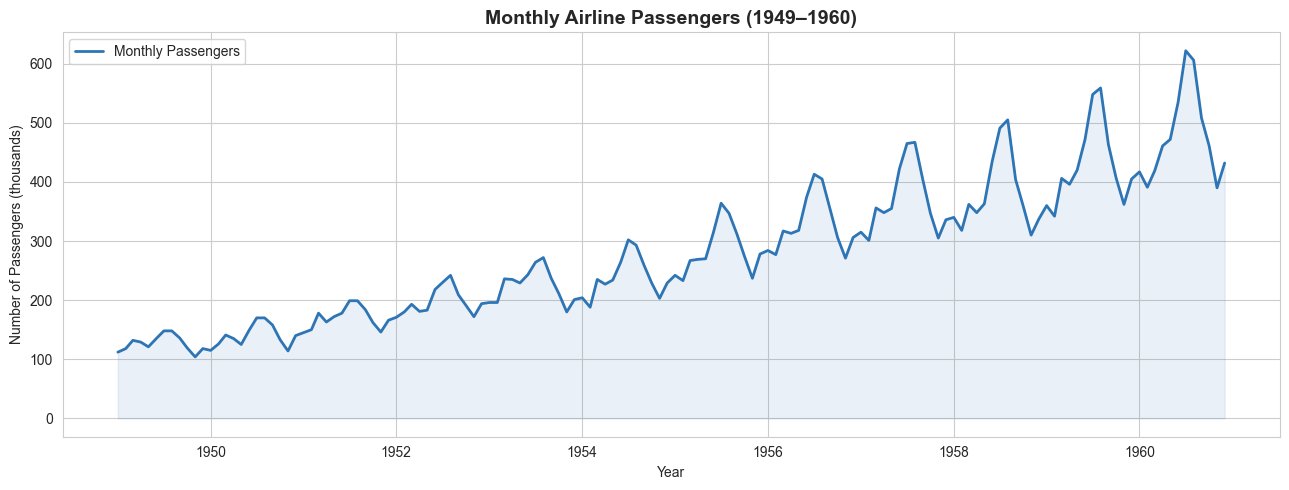

In [13]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df.index, df["Passengers"], color="#2E75B6",
        linewidth=2, label="Monthly Passengers")
ax.fill_between(df.index, df["Passengers"],
                alpha=0.1, color="#2E75B6")
ax.set_title("Monthly Airline Passengers (1949–1960)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Passengers (thousands)")
ax.legend()
plt.tight_layout()
plt.savefig("../passengers_overview.png", dpi=150)
plt.show()

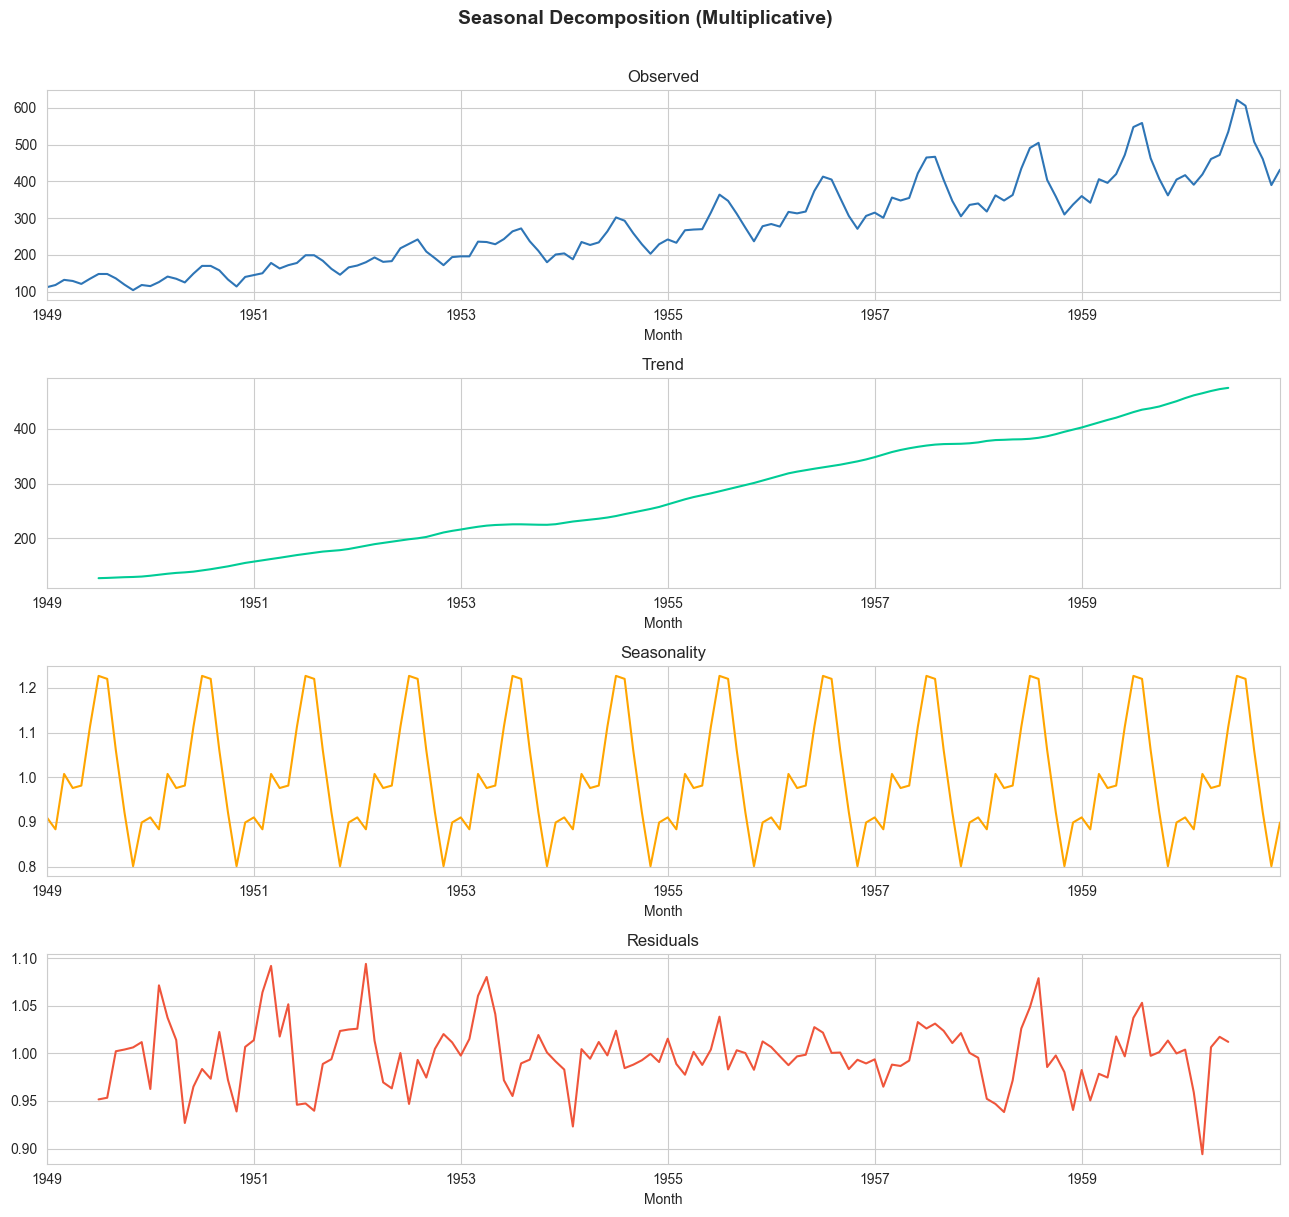

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df["Passengers"],
                                    model="multiplicative",
                                    period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 12))
decomposition.observed.plot(ax=axes[0], color="#2E75B6")
axes[0].set_title("Observed")
decomposition.trend.plot(ax=axes[1], color="#00CC96")
axes[1].set_title("Trend")
decomposition.seasonal.plot(ax=axes[2], color="#FFA500")
axes[2].set_title("Seasonality")
decomposition.resid.plot(ax=axes[3], color="#EF553B")
axes[3].set_title("Residuals")

plt.suptitle("Seasonal Decomposition (Multiplicative)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../decomposition.png", dpi=150)
plt.show()

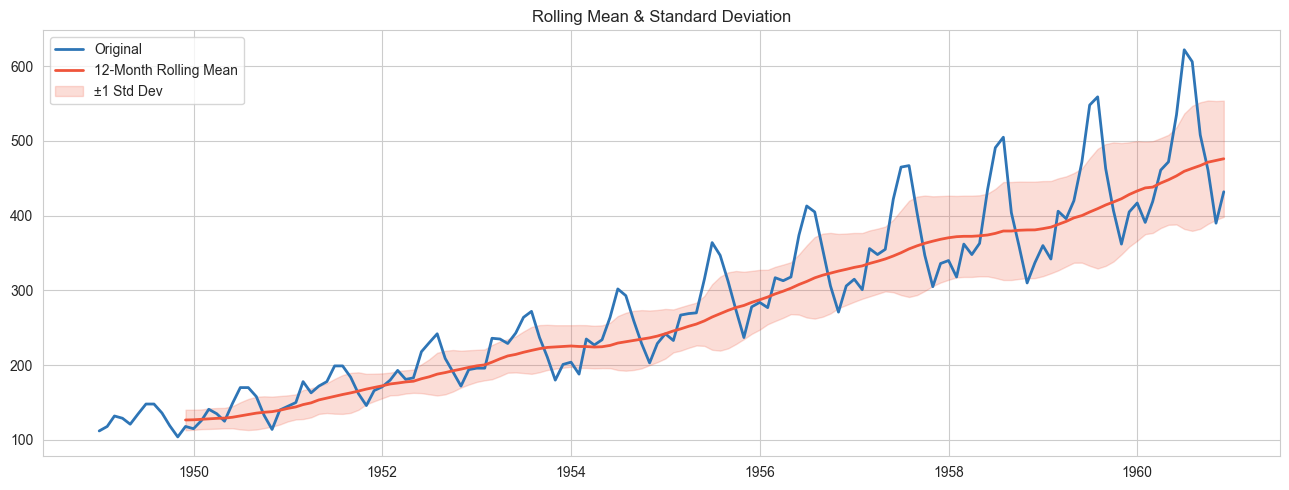

In [15]:
rolling_mean = df["Passengers"].rolling(window=12).mean()
rolling_std = df["Passengers"].rolling(window=12).std()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df["Passengers"], label="Original",
        color="#2E75B6", linewidth=2)
ax.plot(rolling_mean, label="12-Month Rolling Mean",
        color="#EF553B", linewidth=2)
ax.fill_between(df.index,
                rolling_mean - rolling_std,
                rolling_mean + rolling_std,
                alpha=0.2, color="#EF553B",
                label="±1 Std Dev")
ax.set_title("Rolling Mean & Standard Deviation")
ax.legend()
plt.tight_layout()
plt.savefig("../rolling_stats.png", dpi=150)
plt.show()

In [16]:
from statsmodels.tsa.stattools import adfuller

def test_stationarity(series, name="Series"):
    result = adfuller(series.dropna())
    print(f"=== Augmented Dickey-Fuller Test — {name} ===")
    print(f"Test Statistic : {result[0]:.4f}")
    print(f"p-value        : {result[1]:.4f}")
    print(f"Critical Values:")
    for key, val in result[4].items():
        print(f"   {key}: {val:.4f}")
    if result[1] <= 0.05:
        print("✅ Series is STATIONARY (reject null hypothesis)")
    else:
        print("❌ Series is NOT STATIONARY (fail to reject null)")

test_stationarity(df["Passengers"], "Original")
print()

# Differenced series
diff = df["Passengers"].diff().dropna()
test_stationarity(diff, "First Difference")

=== Augmented Dickey-Fuller Test — Original ===
Test Statistic : 0.8154
p-value        : 0.9919
Critical Values:
   1%: -3.4817
   5%: -2.8840
   10%: -2.5788
❌ Series is NOT STATIONARY (fail to reject null)

=== Augmented Dickey-Fuller Test — First Difference ===
Test Statistic : -2.8293
p-value        : 0.0542
Critical Values:
   1%: -3.4817
   5%: -2.8840
   10%: -2.5788
❌ Series is NOT STATIONARY (fail to reject null)


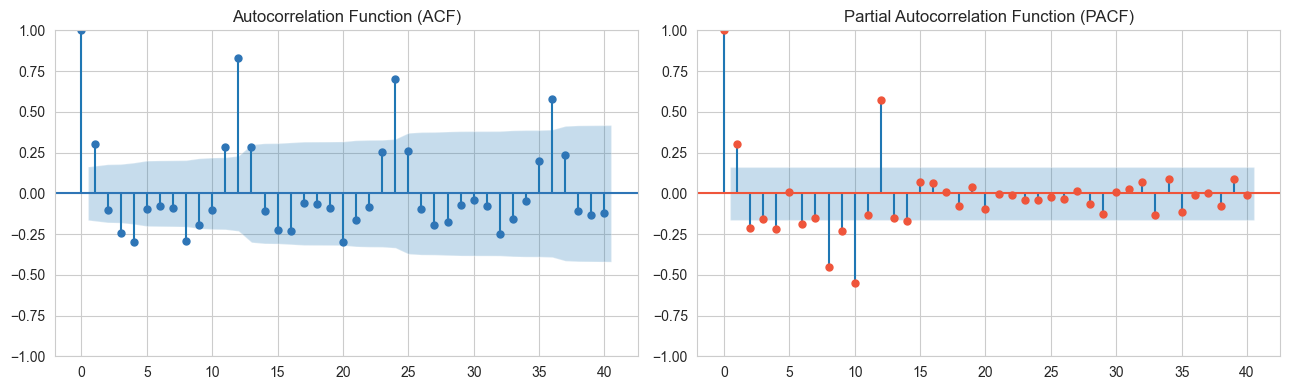

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_acf(df["Passengers"].diff().dropna(),
         lags=40, ax=axes[0], color="#2E75B6")
axes[0].set_title("Autocorrelation Function (ACF)")

plot_pacf(df["Passengers"].diff().dropna(),
          lags=40, ax=axes[1], color="#EF553B",
          method="ywm")
axes[1].set_title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.savefig("../acf_pacf.png", dpi=150)
plt.show()

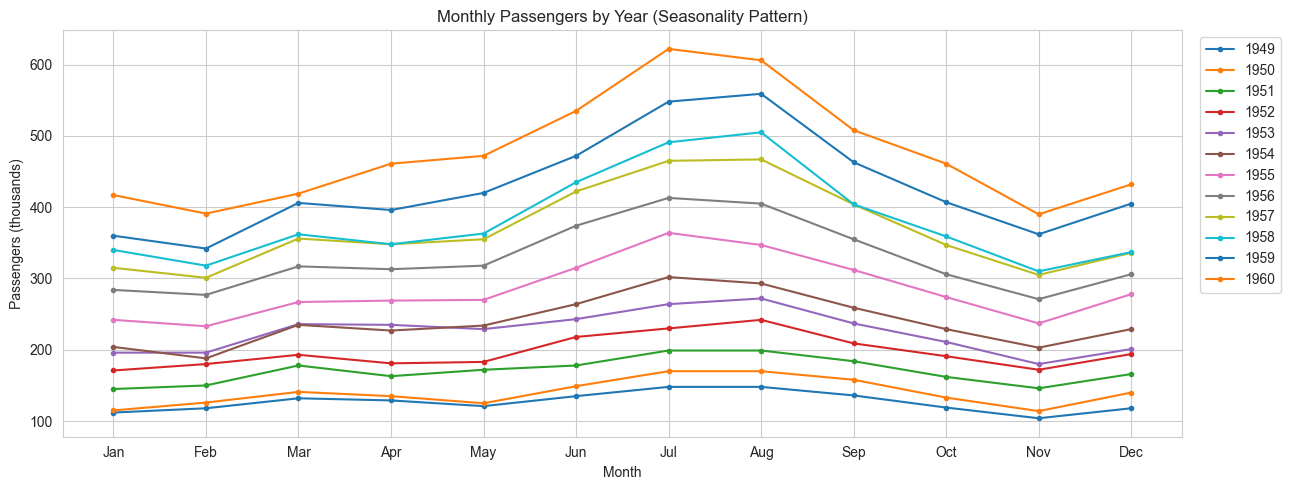

In [18]:
df_yoy = df.copy()
df_yoy["Year"] = df_yoy.index.year
df_yoy["Month_Num"] = df_yoy.index.month

pivot = df_yoy.pivot_table(values="Passengers",
                            index="Month_Num",
                            columns="Year")

plt.figure(figsize=(13, 5))
for year in pivot.columns:
    plt.plot(pivot.index, pivot[year], marker="o",
             markersize=3, label=str(year))
plt.title("Monthly Passengers by Year (Seasonality Pattern)")
plt.xlabel("Month")
plt.ylabel("Passengers (thousands)")
plt.xticks(range(1, 13),
           ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
            "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../seasonal_pattern.png", dpi=150)
plt.show()

## 📋 Key EDA Findings

1. **Strong upward trend** — passenger numbers grew consistently
   from 1949 to 1960
2. **Clear seasonality** — peaks every July/August, dips every
   January/February
3. **Multiplicative seasonality** — the seasonal fluctuations
   grow larger as the trend increases
4. **Series is NOT stationary** — requires differencing before
   ARIMA modelling
5. **ACF shows slow decay** confirming trend; seasonal spikes at
   lags 12, 24 confirm annual seasonality
6. **SARIMA is better suited** than plain ARIMA due to the
   strong seasonal component